In [ ]:
import os

# Ensure relative paths resolve from repo root when run via nbconvert
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [1]:
# Imports
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import pandas as pd
import time
import os
from dlci.core import OPEData
from dlci.kpt import KPT
from dlci.dr_kpt import DRKPT
from dlci.datasets import SyntheticDataset
from dlci.runtime_tables import load_results, build_scenario_table
from dlci.viz import plot_null_diagnostics
from tqdm import tqdm

In [2]:
def run_ope_tests(
    scenario_list,
    method_list,
    sample_size_list,
    num_experiments,
    iterations,
    name_folder,
):
    d = 5
    os.makedirs(name_folder, exist_ok=True)

    # Instantiate test objects once per method (outside loops)
    kpt_linear = KPT(kernel_function="linear", iterations=iterations)
    kpt_rbf = KPT(kernel_function="rbf", iterations=iterations)  # auto median bandwidth

    for scenario_id in tqdm(scenario_list, desc="scenarios"):
        print(f"Scenario {scenario_id}")
        for method in method_list:
            for ns in tqdm(
                sample_size_list,
                desc=f"  ns (scenario {scenario_id}, {method})",
                leave=False,
            ):
                p_values = np.zeros(num_experiments)
                stats = np.zeros(num_experiments)
                times = np.zeros(num_experiments)

                for seed in tqdm(
                    range(num_experiments), desc=f"    seeds (ns={ns})", leave=False
                ):
                    # === Data generation ===
                    dataset = SyntheticDataset(scenario_id, ns=ns, d=d, seed=seed)
                    data = dataset.prepare_ope_data(
                        dataset.policy_pi, dataset.policy_pi_prime
                    )

                    try:
                        t0 = time.time()
                        if method == "PE-linear":
                            result = kpt_linear.test(data)
                            stat, pval = result["stat"], result["pval"]
                        elif method == "KPE":
                            result = kpt_rbf.test(data)
                            stat, pval = result["stat"], result["pval"]
                        elif method == "DR":
                            reg_lambda = DRKPT.tune_reg_lambda(data.L, data.A, data.Y)
                            dr = DRKPT(cross_fit=False, reg_lambda=reg_lambda)
                            result = dr.test(data)
                            stat, pval = result["stat"], result["pval"]
                        elif method == "DR-CF":
                            reg_lambda = DRKPT.tune_reg_lambda(data.L, data.A, data.Y)
                            dr_cf = DRKPT(cross_fit=True, reg_lambda=reg_lambda)
                            result = dr_cf.test(data)
                            stat, pval = result["stat"], result["pval"]
                        else:
                            raise ValueError(f"Unknown method: {method}")
                        elapsed = time.time() - t0
                    except Exception as e:
                        print(f"  seed={seed} method={method} ns={ns}: {e}")
                        stat, pval, elapsed = np.nan, np.nan, 0.0

                    p_values[seed] = pval
                    stats[seed] = stat
                    times[seed] = elapsed

                df = pd.DataFrame({"p_value": p_values, "stat": stats, "time": times})
                fname = f"{name_folder}/ns{ns}_scenario{scenario_id}_{method}.csv"
                df.to_csv(fname, index=False)
                print(f"Saved: {fname}")

In [3]:
num_experiments = 10
iterations = 50
sample_size_list = np.arange(100, 600, 100)
scenario_list = ["I"]
method_list = ["DR-CF", "DR"]
name_folder = "results"

run_ope_tests(
    scenario_list=scenario_list,
    method_list=method_list,
    sample_size_list=sample_size_list,
    num_experiments=num_experiments,
    iterations=iterations,
    name_folder=name_folder,
)

scenarios:   0%|          | 0/1 [00:00<?, ?it/s]

Scenario I


  ns (scenario I, DR-CF):   0%|          | 0/5 [00:00<?, ?it/s]

    seeds (ns=100):   0%|          | 0/10 [00:00<?, ?it/s]

    seeds (ns=100):  30%|███       | 3/10 [00:00<00:00, 29.85it/s]

...

    seeds (ns=500): 100%|██████████| 10/10 [00:08<00:00,  1.13it/s]

  ns (scenario I, DR): 100%|██████████| 5/5 [00:24<00:00,  6.16s/it]

scenarios: 100%|██████████| 1/1 [01:41<00:00, 101.17s/it]

scenarios: 100%|██████████| 1/1 [01:41<00:00, 101.17s/it]

Saved: results/ns500_scenarioI_DR.csv


In [4]:
num_experiments = 10
iterations = 50
sample_size_list = np.arange(100, 450, 100)
scenario_list = ["II", "III", "IV"]
method_list = ["DR-CF"]
name_folder = "results"

run_ope_tests(
    scenario_list=scenario_list,
    method_list=method_list,
    sample_size_list=sample_size_list,
    num_experiments=num_experiments,
    iterations=iterations,
    name_folder=name_folder,
)

scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Scenario II


  ns (scenario II, DR-CF):   0%|          | 0/4 [00:00<?, ?it/s]

    seeds (ns=100):   0%|          | 0/10 [00:00<?, ?it/s]

    seeds (ns=100):  20%|██        | 2/10 [00:00<00:00, 15.63it/s]

...

    seeds (ns=400): 100%|██████████| 10/10 [00:03<00:00,  3.03it/s]

  ns (scenario IV, DR-CF): 100%|██████████| 4/4 [00:07<00:00,  2.53s/it]

scenarios: 100%|██████████| 3/3 [00:23<00:00,  7.96s/it]

scenarios: 100%|██████████| 3/3 [00:23<00:00,  7.94s/it]

Saved: results/ns400_scenarioIV_DR-CF.csv


In [5]:
num_experiments = 10
iterations = 200
sample_size_list = np.arange(100, 450, 100)
scenario_list = ["I", "II", "III", "IV"]
method_list = ["PE-linear", "KPE"]
name_folder = "results"

run_ope_tests(
    scenario_list=scenario_list,
    method_list=method_list,
    sample_size_list=sample_size_list,
    num_experiments=num_experiments,
    iterations=iterations,
    name_folder=name_folder,
)

scenarios:   0%|          | 0/4 [00:00<?, ?it/s]

Scenario I


  ns (scenario I, PE-linear):   0%|          | 0/4 [00:00<?, ?it/s]

    seeds (ns=100):   0%|          | 0/10 [00:00<?, ?it/s]

    seeds (ns=100):  30%|███       | 3/10 [00:00<00:00, 25.91it/s]

...

    seeds (ns=400): 100%|██████████| 10/10 [00:01<00:00,  6.41it/s]

  ns (scenario IV, KPE): 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]

scenarios: 100%|██████████| 4/4 [00:24<00:00,  6.05s/it]

scenarios: 100%|██████████| 4/4 [00:24<00:00,  6.07s/it]

Saved: results/ns400_scenarioIV_KPE.csv


In [6]:
d_results = load_results("results/")

In [7]:
# Plotting functions are in dlci/viz.py


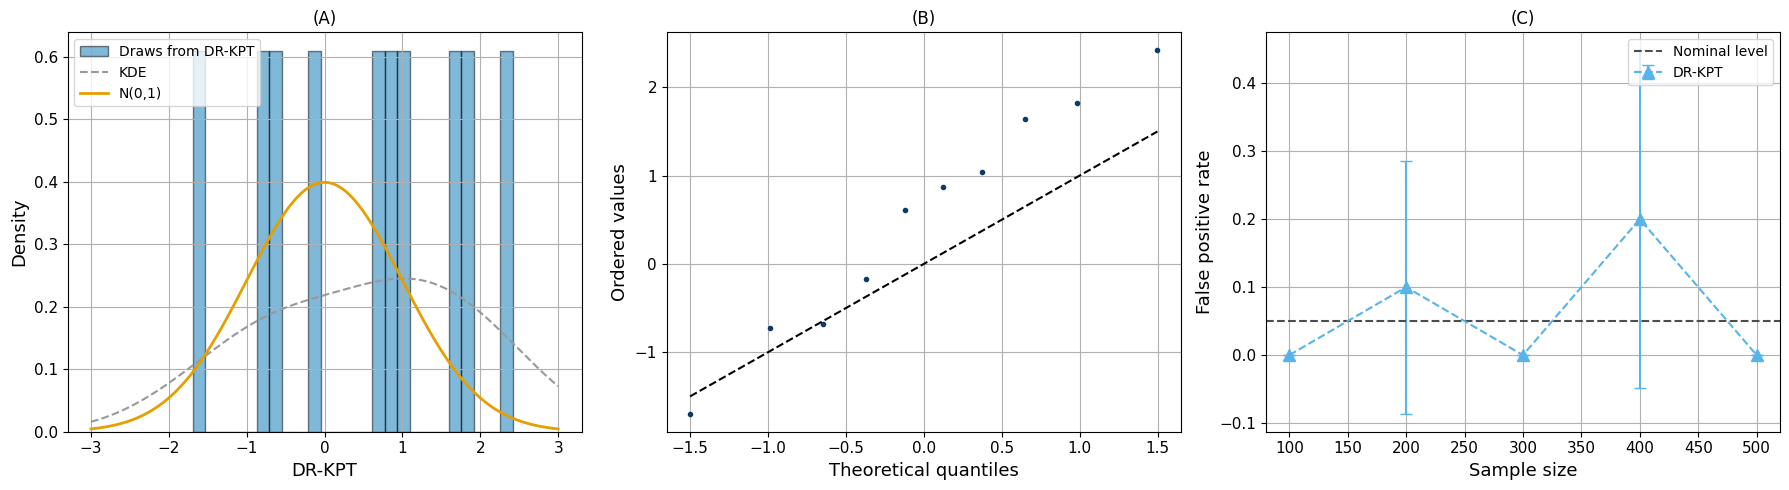

In [8]:
plot_null_diagnostics(
    d_results,
    scenario="I",
    method="DR-CF",
    ns=400,
    results_folder="results/",
    ns_list=np.arange(100, 600, 100),
    confidence_level=0.05,
    save_path="plots/null_scenarioI_errorbar.pdf",
)

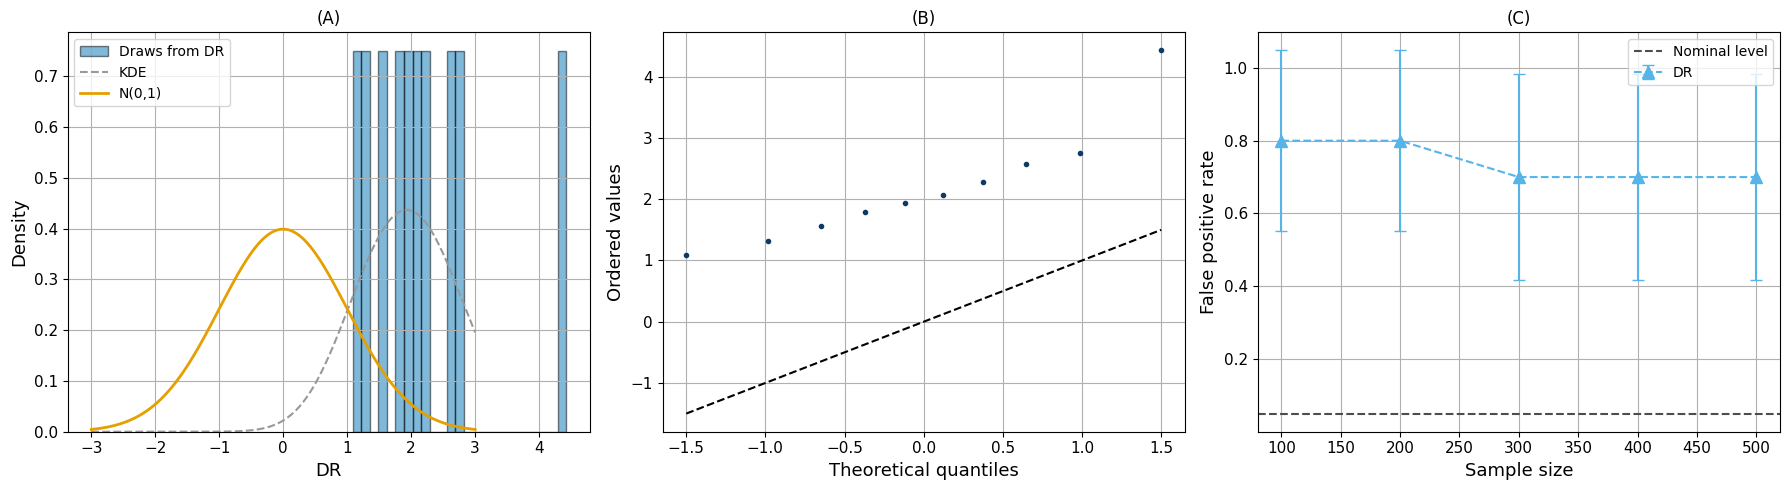

In [9]:
plot_null_diagnostics(
    d_results,
    scenario="I",
    method="DR",
    ns=400,
    results_folder="results/",
    ns_list=np.arange(100, 600, 100),
    confidence_level=0.05,
    save_path="plots/null_dr_nonCF_scenarioI_errorbar.pdf",
)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os


def plot_power_scenarios_observational(
    d,
    scenario_list=["II", "III", "IV"],
    ns_list=[100, 150, 200, 250, 300, 350],
    methods=["PE-linear", "KPE", "DR-CF"],
    name_folder="results/",
    confidence_level=0.05,
    save_path="plots/scenarios234_errorbar.pdf",
):
    # === Styling ===
    plt.rcParams["figure.figsize"] = (16, 4)
    plt.rc("legend", fontsize=12)
    plt.rc("axes", labelsize=15)
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)
    plt.rcParams["axes.grid"] = True

    fig, axs = plt.subplots(1, 3, constrained_layout=True)

    # === Mappings ===
    method_dict = {
        "DR": "DR",
        "KPE": "KPT",
        "DR-CF": "DR-KPT",
        "PE-linear": "PT-linear",
    }
    colors = {
        "PE-linear": "#E69F00",
        "KPE": "#0072B2",
        "DR-CF": "#009E73",
        "DR": "#56B4E9",
    }
    m_dict = {0: "^", 1: "s", 2: "v", 3: "o", 4: "D"}
    scenario_titles = {"II": "(II)", "III": "(III)", "IV": "(IV)"}
    ns_array = np.array(ns_list)

    for col, scenario in enumerate(scenario_list):
        ax = axs[col]
        ax.set_title(scenario_titles[scenario])
        ax.set_ylim((-0.05, 1.05))
        ax.set_xlabel("Sample size")
        ax.set_xticks(ns_list)
        ax.grid(True, linestyle="--", alpha=0.6)
        if col == 0:
            ax.set_ylabel("True positive rate")

        for i, method in enumerate(methods):
            rejection_proportion = []
            for ns in ns_list:
                fname = f"{name_folder}ns{ns}_scenario{scenario}_{method}.csv"
                pvals = d[fname]["p_value"]
                rej = (pvals < confidence_level).mean()
                rejection_proportion.append(rej)
            rejection_proportion = np.array(rejection_proportion)
            varhat = rejection_proportion * (1 - rejection_proportion) / len(pvals)
            ax.errorbar(
                x=ns_array,
                y=rejection_proportion,
                yerr=1.96 * np.sqrt(varhat),
                capsize=4,
                marker=m_dict[i],
                linestyle="--",
                linewidth=1.5,
                markersize=8,
                label=method_dict[method],
                color=colors.get(method, "#333333"),
            )
        ax.axhline(confidence_level, color="black", linestyle=":", linewidth=1)
        ax.legend(loc="lower left")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


from tqdm import tqdm

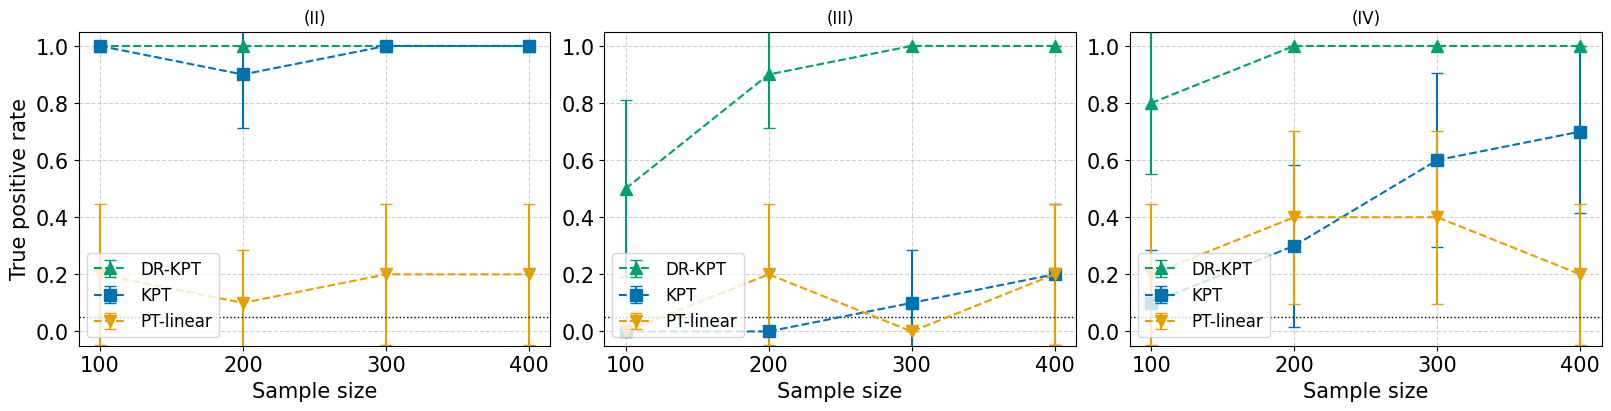

In [11]:
plot_power_scenarios_observational(
    d=d_results,
    scenario_list=["II", "III", "IV"],
    ns_list=[100, 200, 300, 400],
    methods=["DR-CF", "KPE", "PE-linear"],
    name_folder="results/",
    confidence_level=0.05,
    save_path="plots/continuous_scenarios234_errorbar.pdf",
)